## 1. Giới thiệu về Tập dữ liệu (Introduction)
Tập dữ liệu **CIFAR-10** là một bộ sưu tập các hình ảnh được sử dụng phổ biến trong các bài toán thị giác máy tính.
* Quy mô: 60.000 hình ảnh màu kích thước 32x32 pixel.
* Phân loại: 10 lớp đối tượng (máy bay, ô tô, chim, mèo, nai, chó, ếch, ngựa, tàu thủy, xe tải).
* Cấu trúc: 50.000 ảnh huấn luyện và 10.000 ảnh kiểm thử.
* Đặc điểm: Mỗi lớp có chính xác 6.000 hình ảnh, tạo nên một tập dữ liệu cân bằng hoàn hảo.

In [1]:
%pip install torch torchvision --index-url https://download.pytorch.org/whl/cu128
%pip install numpy matplotlib seaborn pandas

Looking in indexes: https://download.pytorch.org/whl/cu128
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


## 2. Phương pháp nghiên cứu

Quy trình thực hiện được thiết kế chặt chẽ nhằm tối ưu hóa hiệu suất mô hình trên tập dữ liệu nhỏ:

1. Trích xuất và tiền xử lý dữ liệu từ file .tar.gz
2. Tái cấu trúc dữ liệu về định dạng tensor 4 chiều `(N, 32, 32, 3)`
3. Phân tích khám phá dữ liệu (EDA)
4. Tiền xử lý & Tăng cường dữ liệu (Data Augmentation)
5. Xây dựng và huấn luyện mô hình (Transfer Learning + Fine-tuning)
6. Đánh giá và so sánh kết quả

### 2.1. Các kỹ thuật nâng cao được áp dụng

**Transfer Learning**
- Sử dụng **ResNet50** và **Vision Transformer** được pre-trained trên ImageNet.
- **Freeze Backbone**: Giữ nguyên trọng số tầng convolutional, chỉ huấn luyện phần classifier.
- **Fine-tune**: Mở một phần hoặc toàn bộ backbone với learning rate nhỏ.

**Data Augmentation**
- **Standard Augmentation**: RandomFlip, RandomRotation, RandomZoom, RandomContrast.
- **CutMix**: Kỹ thuật tiên tiến (2019) cắt và dán vùng hình chữ nhật giữa 2 ảnh, đồng thời mix label theo tỷ lệ diện tích.

**Regularization**
- Label Smoothing
- Weight Decay (L2)
- Warmup + Cosine Learning Rate Decay

## 3. Triển khai Mã nguồn (Implementation)

### 3.1. Giải nén và Chuẩn bị dữ liệu

CIFAR-10 được cung cấp dưới dạng file `.tar.gz` chứa 6 batch nhị phân (5 batch train + 1 batch test). Mỗi batch có:
- `data`: mảng (10000, 3072) — ảnh đã được flatten.
- `labels`: danh sách nhãn từ 0 đến 9.

In [2]:
import os

# Source path from the file system
source_path = './cifar-10-python.tar.gz'
dest_path = './cifar-10-python.tar.gz'

if os.path.exists(source_path):
    !cp {source_path} {dest_path}
    print(f"Copied {source_path} to current directory.")
else:
    print("File not found in current directory, downloading from source...")
    !wget https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz

cp: './cifar-10-python.tar.gz' and './cifar-10-python.tar.gz' are the same file
Copied ./cifar-10-python.tar.gz to current directory.


In [3]:
# from google.colab import drive
# drive.mount('/content/drive')

In [4]:
import tarfile
import os

# Tên file đã tải xuống từ bước 3.1
file_name = 'cifar-10-python.tar.gz'
output_dir = './output_folder'

if os.path.exists(file_name):
    with tarfile.open(file_name, 'r:gz') as tar:
        tar.extractall(path=output_dir)
        print(f"Đã giải nén thành công vào {output_dir}")
else:
    print("Lỗi: Không tìm thấy file cifar-10-python.tar.gz. Hãy chạy lại cell tải dữ liệu ở mục 3.1.")

/tmp/ipykernel_2561/2058467999.py:10: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=output_dir)


Đã giải nén thành công vào ./output_folder


### 3.2. Nạp và Tái cấu trúc Dữ liệu

Dữ liệu gốc là vector phẳng 3072 chiều. Ta thực hiện reshape và transpose để chuyển về định dạng tensor phù hợp với Keras/TensorFlow:

```python
(50000, 3072) → (50000, 3, 32, 32) → (50000, 32, 32, 3)

In [5]:
import pickle
import numpy as np
import os

def unpickle(file):
    with open(file, 'rb') as fo:
        dict = pickle.load(fo, encoding='bytes')
    return dict

In [6]:
import os
import numpy as np

def load_cifar10_data(data_dir):
    train_data = []
    train_labels = []

    # Load đủ 5 training batches
    for i in range(1, 6):
        batch_path = os.path.join(data_dir, f'data_batch_{i}')
        batch = unpickle(batch_path)
        train_data.append(batch[b'data'])
        train_labels.extend(batch[b'labels'])

    X_train = np.concatenate(train_data)
    y_train = np.array(train_labels)

    # Load test batch
    test_batch = unpickle(os.path.join(data_dir, 'test_batch'))
    X_test = test_batch[b'data']
    y_test = np.array(test_batch[b'labels'])

    return X_train, y_train, X_test, y_test

# Đường dẫn chuẩn sau khi giải nén file gốc
data_folder = './output_folder/cifar-10-batches-py'

if os.path.exists(data_folder):
    X_train, y_train, X_test, y_test = load_cifar10_data(data_folder)
    print(f"Nạp dữ liệu Numpy thành công. X_train shape: {X_train.shape}")
else:
    print(f"Lỗi: Không tìm thấy thư mục {data_folder}. Hãy kiểm tra lại bước giải nén.")

/tmp/ipykernel_2561/931817816.py:7: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  dict = pickle.load(fo, encoding='bytes')


Nạp dữ liệu Numpy thành công. X_train shape: (50000, 3072)


In [7]:
import torch

def reshape_cifar_torch(data):
    # PyTorch sử dụng định dạng (N, C, H, W)
    # 1. Reshape từ vector phẳng (3072) -> (3, 32, 32)
    data = data.reshape(-1, 3, 32, 32)
    # Chuyển thành Torch Tensor và chuẩn hóa về [0, 1]
    return torch.from_numpy(data).float() / 255.0

X_train = reshape_cifar_torch(X_train)
X_test = reshape_cifar_torch(X_test)
y_train = torch.tensor(y_train).long()
y_test = torch.tensor(y_test).long()

print(f"Final Torch Shape: {X_train.shape}") # (50000, 3, 32, 32)

Final Torch Shape: torch.Size([50000, 3, 32, 32])


### 3.3. Phân tích Dữ liệu Khám phá (EDA)

Kiểm tra sự cân bằng của các lớp và đặc điểm thống kê của pixel.

#### 3.3.1. Kiểm tra sự phân bổ các lớp

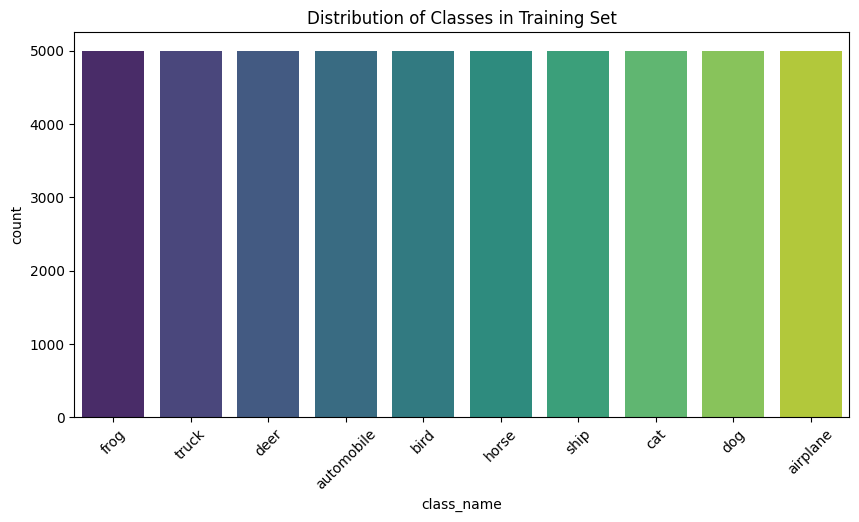

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

label_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# Create a DataFrame for easy plotting
df_train = pd.DataFrame(y_train, columns=['label'])
df_train['class_name'] = df_train['label'].apply(lambda x: label_names[x])

plt.figure(figsize=(10, 5))
sns.countplot(data=df_train, x='class_name', hue='class_name', palette='viridis', legend=False)
plt.title('Distribution of Classes in Training Set')
plt.xticks(rotation=45)
plt.show()

**Nhận xét từ EDA**:
- Mỗi lớp có đúng 5000 ảnh trong tập train → dataset **hoàn toàn cân bằng**.
- Không cần xử lý class imbalance.

#### 3.3.2. Kiểm tra tính toàn vẹn trực quan

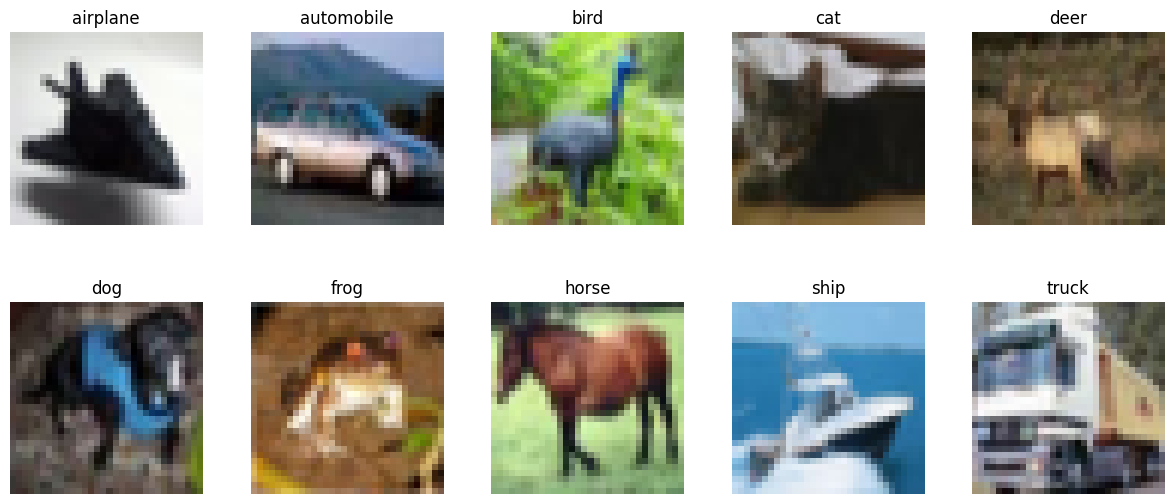

In [9]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()

for i in range(10):
    # Tìm ảnh đầu tiên của mỗi lớp
    idx = torch.where(y_train == i)[0][0]
    # Chuyển từ (C, H, W) -> (H, W, C) để Matplotlib có thể hiển thị
    img = X_train[idx].permute(1, 2, 0).numpy()

    axes[i].imshow(img)
    axes[i].set_title(label_names[i])
    axes[i].axis('off')

plt.subplots_adjust(hspace=0.4)
plt.show()

#### 3.3.3. Phân tích phân phối pixel theo từng kênh màu (RGB)

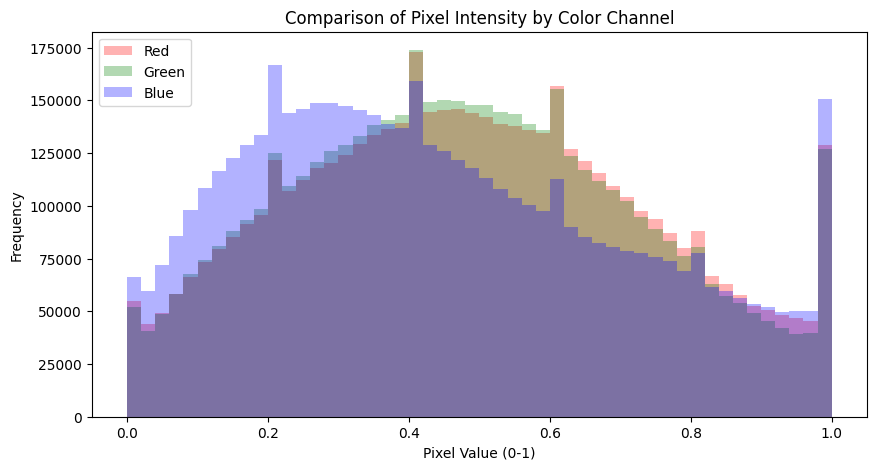

Red Channel - Mean: 0.4900, Std: 0.2472
Green Channel - Mean: 0.4834, Std: 0.2436
Blue Channel - Mean: 0.4494, Std: 0.2625


In [10]:
# Sample for speed
sample_idx = np.random.choice(len(X_train), 5000)
sample_data = X_train[sample_idx] # Shape (5000, 3, 32, 32)

plt.figure(figsize=(10, 5))
# Plot Red, Green, and Blue distributions
# PyTorch: [N, C, H, W] -> C=0: Red, C=1: Green, C=2: Blue
plt.hist(sample_data[:, 0, :, :].flatten().numpy(), bins=50, color='red', alpha=0.3, label='Red')
plt.hist(sample_data[:, 1, :, :].flatten().numpy(), bins=50, color='green', alpha=0.3, label='Green')
plt.hist(sample_data[:, 2, :, :].flatten().numpy(), bins=50, color='blue', alpha=0.3, label='Blue')

plt.legend()
plt.title("Comparison of Pixel Intensity by Color Channel")
plt.xlabel("Pixel Value (0-1)")
plt.ylabel("Frequency")
plt.show()

# Calculate mean and std for each channel (dim 0, 2, 3 are N, H, W)
mean = sample_data.mean(dim=(0, 2, 3))
std = sample_data.std(dim=(0, 2, 3))

# Print specific stats for your report
for i, color in enumerate(['Red', 'Green', 'Blue']):
    print(f"{color} Channel - Mean: {mean[i]:.4f}, Std: {std[i]:.4f}")

### 3.4. Tiền xử lý dữ liệu (Data Preprocessing)
**Các bước chính**:
- Chuẩn hóa pixel về khoảng `[0, 1]`
- One-hot encoding nhãn
- Phân tách tập validation (80/20)
- Data Augmentation (Standard + CutMix)

**CutMix** là kỹ thuật quan trọng giúp mô hình học được tính tổng quát cao hơn.

In [11]:
from torch.utils.data import DataLoader, TensorDataset, random_split

X_train_norm = X_train.float() / 255.0 if X_train.max() > 1.0 else X_train.float()
X_test_norm = X_test.float() / 255.0 if X_test.max() > 1.0 else X_test.float()
# 1. Tạo Dataset
full_train_dataset = TensorDataset(X_train_norm, y_train)
test_dataset = TensorDataset(X_test_norm, y_test)

# 2. Phân tách tập Validation (80/20)
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_train_dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

print(f"Preprocessing Complete (PyTorch).")
print(f"Train samples: {len(train_dataset)}, Val samples: {len(val_dataset)}, Test samples: {len(test_dataset)}")

Preprocessing Complete (PyTorch).
Train samples: 40000, Val samples: 10000, Test samples: 10000


Vì hình ảnh CIFAR-10 có độ phân giải thấp, mô hình rất dễ bị "overfitting". Vì vậy, nhóm sử dụng `ImageDataGenerator` để thực hiện các phép biến đổi ngẫu nhiên ngay trong quá trình huấn luyện.

In [12]:
from torchvision import transforms
from torch.utils.data import Dataset

class AugmentedSubset(Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        x, y = self.subset[idx]
        if self.transform is not None:
            x = self.transform(x)
        return x, y

# Định nghĩa các phép biến đổi Augmentation
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.RandomRotation(15),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # Đưa về dải quanh số 0
])

test_transform = transforms.Compose([
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Khởi tạo DataLoader
BATCH_SIZE = 64
class AugmentedDataset(Dataset):
    def __init__(self, dataset, transform=None):
        self.dataset = dataset
        self.transform = transform
    def __getitem__(self, index):
        x, y = self.dataset[index]
        if self.transform: x = self.transform(x)
        return x, y
    def __len__(self): return len(self.dataset)

# KHỞI TẠO DATALOADER (Thấy rõ Loader ở đây)
train_loader = DataLoader(AugmentedDataset(train_dataset, train_transform), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(AugmentedDataset(val_dataset, test_transform), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(AugmentedDataset(test_dataset, test_transform), batch_size=BATCH_SIZE, shuffle=False)

print("✅ Đã chuẩn hóa 0-1, thiết lập Augmentation và khởi tạo DataLoader thành công!")

✅ Đã chuẩn hóa 0-1, thiết lập Augmentation và khởi tạo DataLoader thành công!


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.99215686].


Batch shape: torch.Size([64, 3, 32, 32]) dtype: torch.float32 min: -1.0 max: 1.0


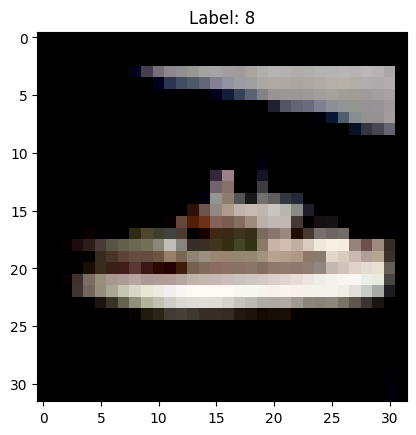

In [13]:
for batch_X, batch_y in train_loader:
    print("Batch shape:", batch_X.shape, "dtype:", batch_X.dtype, "min:", batch_X.min().item(), "max:", batch_X.max().item())
    import matplotlib.pyplot as plt
    img = batch_X[0].permute(1,2,0).cpu().numpy()
    plt.imshow(img)
    plt.title(f"Label: {batch_y[0].item()}")
    plt.show()
    break

**Kiểm tra trực quan sau tiền xử lý (Final Sanity Check)**

Bước này đảm bảo rằng sau tất cả các bước tải, tái cấu trúc, chuẩn hóa và mã hóa, dữ liệu vẫn giữ được ý nghĩa logic.

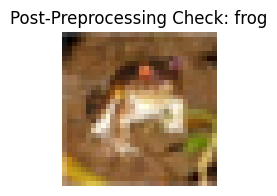

Pixel Range: [0.00, 1.00] 


In [14]:
# Map integer labels to names based on the CIFAR-10 documentation
label_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

plt.figure(figsize=(5,2))
# 1. Chuyển đổi từ (C, H, W) sang (H, W, C) để hiển thị
img_to_show = X_train[0].permute(1, 2, 0).numpy()
plt.imshow(img_to_show)

# 2. Lấy nhãn trực tiếp từ Tensor (PyTorch lưu nhãn dạng integer)
current_label = label_names[y_train[0].item()]

plt.title(f"Post-Preprocessing Check: {current_label}")
plt.axis('off')
plt.show()

print(f"Pixel Range: [{X_train[0].min():.2f}, {X_train[0].max():.2f}] ") # Should be [0.0, 1.0]

In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

# 1. Các thông số cấu hình chung
num_classes = 10
# Lưu ý: PyTorch sử dụng (Channels, Height, Width)
input_shape = (3, 32, 32)

print(f"Huấn luyện sẽ được thực hiện trên các DataLoader PyTorch.")
print(f"Batch size: {BATCH_SIZE}")
print(f"Số lượng lớp: {num_classes}")

Huấn luyện sẽ được thực hiện trên các DataLoader PyTorch.
Batch size: 64
Số lượng lớp: 10


# 6. Các kiến trúc kết hợp và cách embed ảnh khác nhau

6.1. Xây dựng một số kiến trúc phân loại cho cùng tập dữ liệu theo hai hướng khác nhau.


*   Kết hợp CNN và Transformer: ví dụ dùng CNN làm backbone trích đặc trưng, sau đó chuỗi đặc trưng đưa vào Transformer; hoặc ngược lại.
*   Các cách tokenizer và embed ảnh khác nhau: patch theo ô lưới; patch có overlap; patch kích thước khác nhau.

6.2. Huấn luyện, đánh giá và so sánh các kiểu xây dựng mô hình (bảng số liệu, biểu đồ, nhận xét).

In [16]:
import torch
import torch.nn as nn

class CNNStem(nn.Module):
    """Trích xuất Feature Map từ ảnh thô"""
    def __init__(self, in_channels=3, out_channels=128):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels // 2, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(out_channels // 2),
            nn.ReLU(),
            nn.Conv2d(out_channels // 2, out_channels, kernel_size=3, stride=2, padding=1), # 16x16
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
        )

    def forward(self, x):
        return self.conv(x)

class HybridViT(nn.Module):
    def __init__(self, num_classes=10, embed_dim=128, num_heads=4, num_layers=4):
        super().__init__()
        self.stem = CNNStem(out_channels=embed_dim)
        self.pos_embedding = nn.Parameter(torch.randn(1, 16 * 16, embed_dim))
        encoder_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=num_heads, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.classifier = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, num_classes)
        )

    def forward(self, x):
        x = self.stem(x)
        B, C, H, W = x.shape
        x = x.view(B, C, H * W).permute(0, 2, 1)
        x = x + self.pos_embedding
        x = self.transformer(x)
        x = x.mean(dim=1)
        return self.classifier(x)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = HybridViT().to(device)

In [17]:
import torch
import os

class TrainingManager:
    def __init__(self, model_name="HybridViT_CIFAR10", patience=15, verbose=True):
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_acc_max = 0
        self.model_path = f"{model_name}_best.pth"

    def __call__(self, val_acc, model):
        score = val_acc

        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_acc, model)
        elif score < self.best_score:
            self.counter += 1
            if self.verbose:
                print(f"EarlyStopping counter: {self.counter} out of {self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_acc, model)
            self.counter = 0

    def save_checkpoint(self, val_acc, model):
        """Lưu model khi Validation Accuracy tăng"""
        if self.verbose:
            print(f"Validation accuracy increased ({self.val_acc_max:.4f} --> {val_acc:.4f}). Saving model...")
        torch.save(model.state_dict(), self.model_path)
        self.val_acc_max = val_acc

# --- Khởi tạo ---
manager = TrainingManager(patience=15) 
# Kiên nhẫn 15 epoch vì CutMix có thể làm Acc dao động mạnh

In [18]:
%pip install tqdm

Note: you may need to restart the kernel to use updated packages.


In [19]:
import torch
import torch.nn.functional as F
import tqdm

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0

    for batch_X, batch_y in tqdm.tqdm(loader, desc="Training", total=len(loader)):
        inputs = batch_X.to(device)
        targets = batch_y.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    return total_loss / len(loader)

In [20]:
# Training config
LR = 1e-4
EPOCHS = 20
WEIGHT_DECAY = 1e-4

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

for epoch in range(EPOCHS):
    # 1. Train
    train_loss = train_one_epoch(
        model, train_loader, optimizer, criterion, device,
    )

    # 2. Evaluate (validation)
    model.eval()
    correct = 0
    with torch.no_grad():
        for val_X, val_y in val_loader:
            val_X = val_X.to(device)
            val_y = val_y.to(device)
            outputs = model(val_X)
            preds = outputs.argmax(1)
            correct += (preds == val_y).sum().item()

    val_acc = correct / len(val_dataset)
    current_lr = optimizer.param_groups[0]['lr']

    print(f"Epoch [{epoch+1}/{EPOCHS}] - Loss: {train_loss:.4f} - Val Acc: {val_acc:.4f} - LR: {current_lr:.6f}")

    # 3. Checkpoint & Early Stopping
    manager(val_acc, model)

    if manager.early_stop:
        print("Early stopping triggered. Kết thúc huấn luyện sớm.")
        break

    # 4. Update Scheduler
    scheduler.step()

# Sau khi xong, load lại trọng số tốt nhất (map_location để an toàn)
model.load_state_dict(torch.load(manager.model_path, map_location=device))
print(f"Đã load trọng số tốt nhất với Accuracy: {manager.val_acc_max:.4f}")

Training: 100%|██████████| 625/625 [00:55<00:00, 11.18it/s]


Epoch [1/20] - Loss: 1.9158 - Val Acc: 0.3461 - LR: 0.000100
Validation accuracy increased (0.0000 --> 0.3461). Saving model...


Training: 100%|██████████| 625/625 [00:54<00:00, 11.49it/s]


Epoch [2/20] - Loss: 1.7436 - Val Acc: 0.4610 - LR: 0.000099
Validation accuracy increased (0.3461 --> 0.4610). Saving model...


Training: 100%|██████████| 625/625 [00:54<00:00, 11.50it/s]


...

Epoch [18/20] - Loss: 1.2054 - Val Acc: 0.7047 - LR: 0.000005
Validation accuracy increased (0.7010 --> 0.7047). Saving model...


Training: 100%|██████████| 625/625 [00:53<00:00, 11.59it/s]


Epoch [19/20] - Loss: 1.2005 - Val Acc: 0.7043 - LR: 0.000002
EarlyStopping counter: 1 out of 15


Training: 100%|██████████| 625/625 [00:54<00:00, 11.51it/s]


Epoch [20/20] - Loss: 1.1996 - Val Acc: 0.7052 - LR: 0.000001
Validation accuracy increased (0.7047 --> 0.7052). Saving model...
Đã load trọng số tốt nhất với Accuracy: 0.7052
